Exercise 0

In [6]:
import pandas as pd
import re

# Load the CSV file. It seems to have a similar structure to the Excel file,
# with the matrix starting after some initial header rows.
# We'll need to inspect the CSV to determine the correct 'header' and 'index_col'.
# Assuming the structure is similar to the Excel where the actual header is on row 3 (index 2).
file_path = '/content/Kobori_ACIE_2016_Supporting_Data (2).csv'

# Attempt to load the CSV, skipping initial metadata rows.
# Based on the structure of the Excel file, the matrix headers are on the 3rd row (index 2).
# The first column contains the row labels.
df_matrix = pd.read_csv(file_path, header=2, index_col=0)

# Display the first few rows/cols of the matrix to verify its structure
print("First 5 rows and columns of the loaded CSV matrix:")
display(df_matrix.iloc[:5, :5])


First 5 rows and columns of the loaded CSV matrix:


,A7U,A7G,A7C,A8U,A8G
A7U,0.07,NaN,NaN,0.07,0.09
A7G,NaN,0.49,NaN,0.10,0.28
A7C,NaN,NaN,0.04,0.06,0.05
A8U,0.07,0.10,0.06,0.49,NaN
A8G,0.09,0.28,0.05,NaN,0.71


Now, let's infer the wild-type sequence. As you clarified, the first character of each column/row represents the original nucleotide at that position.

Now, let's infer the wild-type sequence. As you clarified, the first character of each column/row represents the original nucleotide at that position.

In [12]:
import pandas as pd
import re

# Extract unique single mutation strings from the index (or columns, they should be the same)
single_mutation_strings = df_matrix.index.tolist()

# Initialize dictionary to store wild-type nucleotides
wt_nucleotides = {}

# Parse each single mutation string (e.g., 'A7U')
for mutation_str in single_mutation_strings:
    if isinstance(mutation_str, str) and re.match(r'([ACGU])(\d+)([ACGU])', mutation_str):
        original_nt, position_str, _ = re.match(r'([ACGU])(\d+)([ACGU])', mutation_str).groups()
        position = int(position_str)
        # Store the original nucleotide (first character) as the wild-type for this position
        wt_nucleotides[position] = original_nt

# Sort the positions and reconstruct the 48-nt wild-type sequence for the mutated region
sorted_positions = sorted(wt_nucleotides.keys())
mutated_region_wt_sequence = ''.join([wt_nucleotides[p] for p in sorted_positions])

# The problem states the 5' end (unmutated) has 6 nucleotides, but provides 'CCGCCUU' (7 nucleotides).
# Given that mutations start at position 7 (e.g., A7U), it implies position 7 is part of the mutated region,
# and its wild-type base is defined by the mutation string (e.g., 'A' for A7U).
# Therefore, the fixed 5' prime sequence should be 6 nucleotides long: 'CCGCCU'.
fixed_5_prime_sequence = "CCGCCU" # Corrected length 6
full_wt_sequence = fixed_5_prime_sequence + mutated_region_wt_sequence

print(f"Reconstructed 48-nt mutated region WT sequence: {mutated_region_wt_sequence}")
print(f"Full WT RNA sequence (54 nucleotides): {full_wt_sequence}")

# Function to apply mutations to the wild-type sequence
def apply_mutations_to_sequence(wt_seq, mutation_str):
    if mutation_str == 'WT':
        return wt_seq

    mutated_seq_list = list(wt_seq)
    mutations = mutation_str.split('_') # Handle both single and double mutations

    for mut in mutations:
        match = re.match(r'([ACGU])(\d+)([ACGU])', mut)
        if match:
            original_nt_in_mut, position_str, mutated_nt = match.groups()
            position_1_indexed = int(position_str)
            index_0_indexed = position_1_indexed - 1

            # This check now ensures consistency with the inferred WT sequence.
            if wt_seq[index_0_indexed] != original_nt_in_mut:
                print(f"Warning: Wild-type base mismatch at position {position_1_indexed}. Expected {original_nt_in_mut}, found {wt_seq[index_0_indexed]} in full_wt_sequence. Using found.")

            mutated_seq_list[index_0_indexed] = mutated_nt
    return "".join(mutated_seq_list)

# Helper function to parse mutation details for identity columns
def parse_mutation_details(mutation_str):
    if mutation_str == 'WT':
        return {'Original Nucleotide': None, 'Location': None, 'Mutant Nucleotide': None}

    original_nts = []
    positions = []
    mutant_nts = []

    mutations = mutation_str.split('_')
    for mut in mutations:
        match = re.match(r'([ACGU])(\d+)([ACGU])', mut)
        if match:
            original_nts.append(match.group(1))
            positions.append(int(match.group(2)))
            mutant_nts.append(match.group(3))

    # Join for display in single columns for multi-mutations
    return {
        'Original Nucleotide': ','.join(original_nts) if original_nts else None,
        'Location': ','.join(map(str, positions)) if positions else None,
        'Mutant Nucleotide': ','.join(mutant_nts) if mutant_nts else None
    }


# Create a flat dataframe containing every mutational variant and its relative activity.
variant_data = []

# Add the 'WT' entry with Relative Activity 1.0
wt_details = parse_mutation_details('WT')
variant_data.append({'Variant': 'WT', 'Relative Activity': 1.0, 'Type': 'Wild-Type', 'Sequence': full_wt_sequence, **wt_details})

# Set of valid single mutation strings (to filter out any non-mutation entries if present)
valid_single_mut_strs = set()

# Get single mutants from the diagonal of the matrix
for mut_str in df_matrix.index:
    if isinstance(mut_str, str) and re.match(r'([ACGU])(\d+)([ACGU])', mut_str):
        valid_single_mut_strs.add(mut_str)
        single_mutant_ra = df_matrix.loc[mut_str, mut_str]
        mutant_sequence = apply_mutations_to_sequence(full_wt_sequence, mut_str)
        single_mut_details = parse_mutation_details(mut_str)
        variant_data.append({'Variant': mut_str, 'Relative Activity': single_mutant_ra, 'Type': 'Single', 'Sequence': mutant_sequence, **single_mut_details})

# Get double mutants from off-diagonal entries
# Iterate through all combinations of rows and columns
for mut1_str in df_matrix.index:
    for mut2_str in df_matrix.columns:
        # Only process if both are valid single mutation strings and they are different
        if mut1_str in valid_single_mut_strs and mut2_str in valid_single_mut_strs and mut1_str != mut2_str:
            double_mutant_ra = df_matrix.loc[mut1_str, mut2_str]

            # Only add if the activity is not NaN (meaning it's a valid data point)
            if pd.notna(double_mutant_ra):
                # Ensure a consistent naming convention for double mutants, e.g., 'A7U_C15G'
                # Sort alphabetically to avoid duplicates like 'A7U_C15G' and 'C15G_A7U'
                sorted_mut_parts = sorted([mut1_str, mut2_str])
                combined_mut_str = f"{sorted_mut_parts[0]}_{sorted_mut_parts[1]}"

                # Generate sequence for double mutant
                double_mutant_sequence = apply_mutations_to_sequence(full_wt_sequence, combined_mut_str)
                double_mut_details = parse_mutation_details(combined_mut_str)
                variant_data.append({'Variant': combined_mut_str, 'Relative Activity': double_mutant_ra, 'Type': 'Double', 'Sequence': double_mutant_sequence, **double_mut_details})

# Create DataFrame and drop potential duplicates (e.g., if matrix is symmetric and both halves are filled)
df_mutational_variants = pd.DataFrame(variant_data).drop_duplicates(subset=['Variant'])

print(f"\nFirst 5 rows of the combined mutational variants DataFrame (including WT, singles, and doubles) with new identity columns:")
display(df_mutational_variants.head())
print(f"Total number of variants (including WT, single and double): {len(df_mutational_variants)}")


Reconstructed 48-nt mutated region WT sequence: AACACUGCCAAUGCCGGUCCCAAGCCCGGAUAAAAGUGGAGGGGGCGG
Full WT RNA sequence (54 nucleotides): CCGCCUAACACUGCCAAUGCCGGUCCCAAGCCCGGAUAAAAGUGGAGGGGGCGG

First 5 rows of the combined mutational variants DataFrame (including WT, singles, and doubles) with new identity columns:


,Variant,Relative Activity,Type,Sequence,Original Nucleotide,Location,Mutant Nucleotide
0,WT,1.00,Wild-Type,CCGCCUAACACUGCCAAUGCCGGUCCCAAGCCCGGAUAAAAGUGGA...,None,None,None
1,A7U,0.07,Single,CCGCCUUACACUGCCAAUGCCGGUCCCAAGCCCGGAUAAAAGUGGA...,A,7,U
2,A7G,0.49,Single,CCGCCUGACACUGCCAAUGCCGGUCCCAAGCCCGGAUAAAAGUGGA...,A,7,G
3,A7C,0.04,Single,CCGCCUCACACUGCCAAUGCCGGUCCCAAGCCCGGAUAAAAGUGGA...,A,7,C
4,A8U,0.49,Single,CCGCCUAUCACUGCCAAUGCCGGUCCCAAGCCCGGAUAAAAGUGGA...,A,8,U


Total number of variants (including WT, single and double): 10297


Exercise 1

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Extract single mutants
df_single_mutants = df_mutational_variants[df_mutational_variants['Type'] == 'Single'].copy()

# Convert 'Location' to integer for proper grouping and sorting
df_single_mutants['Location'] = df_single_mutants['Location'].astype(int)

print("First 5 rows of single mutants DataFrame:")
display(df_single_mutants.head())
print(f"Total number of single mutants: {len(df_single_mutants)}")


First 5 rows of single mutants DataFrame:


,Variant,Relative Activity,Type,Sequence,Original Nucleotide,Location,Mutant Nucleotide
1,A7U,0.07,Single,CCGCCUUACACUGCCAAUGCCGGUCCCAAGCCCGGAUAAAAGUGGA...,A,7,U
2,A7G,0.49,Single,CCGCCUGACACUGCCAAUGCCGGUCCCAAGCCCGGAUAAAAGUGGA...,A,7,G
3,A7C,0.04,Single,CCGCCUCACACUGCCAAUGCCGGUCCCAAGCCCGGAUAAAAGUGGA...,A,7,C
4,A8U,0.49,Single,CCGCCUAUCACUGCCAAUGCCGGUCCCAAGCCCGGAUAAAAGUGGA...,A,8,U
5,A8G,0.71,Single,CCGCCUAGCACUGCCAAUGCCGGUCCCAAGCCCGGAUAAAAGUGGA...,A,8,G


Total number of single mutants: 144


### Step 2: Define the mutational sensitivity at each position

We will calculate the following for each position:
1.  **Mean Relative Activity** of single mutants at that position.
2.  **Minimum Relative Activity** of single mutants at that position.
3.  **Sensitivity Score** defined as (1 - mean relative activity).

In [15]:
# Calculate mean, min relative activity, and sensitivity score for each position
positional_sensitivity = df_single_mutants.groupby('Location')['Relative Activity'].agg(
    mean_activity='mean',
    min_activity='min'
).reset_index()

# Calculate sensitivity score: (1 - mean relative activity)
positional_sensitivity['sensitivity_score'] = 1 - positional_sensitivity['mean_activity']

# Sort by position for plotting
positional_sensitivity = positional_sensitivity.sort_values('Location')

print("Positional Sensitivity Data:")
display(positional_sensitivity.head())


Positional Sensitivity Data:


,Location,mean_activity,min_activity,sensitivity_score
0,7,0.200000,0.04,0.800000
1,8,0.423333,0.07,0.576667
2,9,0.730000,0.48,0.270000
3,10,0.360000,0.05,0.640000
4,11,0.826667,0.70,0.173333


### Step 3: Plot Mutational Sensitivity

Let's visualize these three metrics across the RNA sequence.

### Analysis of Exercise 1: Single-mutant sensitivity – which positions matter?

**Consistency of Sensitivity Metrics:**
*   The three metrics – Mean Relative Activity, Minimum Relative Activity, and Sensitivity Score (1 - Mean Relative Activity) – are generally consistent. The `Sensitivity Score` plot is essentially an inverted mirror image of the `Mean Relative Activity` plot, which is expected by its definition. Positions with low mean activity will have high sensitivity scores, indicating they are crucial. The `Minimum Relative Activity` plot also largely follows a similar trend to the sensitivity score; positions where even one mutation severely reduces activity (low minimum) are often highly sensitive overall.
*   **Mean Relative Activity:** This metric tells us, on average, how much a position tolerates *any* change. Lower mean activity implies that, across all possible single mutations at that position, the ribozyme's activity significantly decreases, suggesting it's a generally conserved and important position.
*   **Minimum Relative Activity:** This highlights the *most drastic* impact a single mutation can have at a given position. A very low minimum activity indicates that at least one specific mutation at that position is highly detrimental to function, marking it as a potentially critical base where even a single incorrect nucleotide can severely impair the ribozyme.
*   **Sensitivity Score (1 - Mean Relative Activity):** This provides a direct measure of how intolerant a position is to mutation. A higher sensitivity score means the position is less tolerant to mutations and thus more essential for ribozyme function. This is often the most straightforward metric for ranking overall positional importance.

**Top 10 Most Sensitive Nucleotides vs. Literature:**
Our analysis, based on the `sensitivity_score`, identified the following 10 most sensitive nucleotides:

| Location | Mean Activity | Min Activity | Sensitivity Score |
| :------- | :------------ | :----------- | :---------------- |
| 30       | 0.0400        | 0.04         | 0.9600            |
| 13       | 0.0767        | 0.03         | 0.9233            |
| 46       | 0.0833        | 0.08         | 0.9166            |
| 48       | 0.1200        | 0.10         | 0.8800            |
| 49       | 0.1867        | 0.07         | 0.8133            |
| 32       | 0.1900        | 0.15         | 0.8100            |
| 7        | 0.2000        | 0.04         | 0.8000            |
| 29       | 0.2200        | 0.05         | 0.7800            |
| 45       | 0.2500        | 0.06         | 0.7500            |
| 27       | 0.2767        | 0.13         | 0.7233            |


The 10 highly conserved nucleotides from the literature are: **A7, A8, G23, G24, A28, A29, G30, C32, G45, A46** (positions: 7, 8, 23, 24, 28, 29, 30, 32, 45, 46).

Comparing our top 10 list with the literature:
*   **Matching positions (6/10):** Positions **7, 29, 30, 32, 45, 46** are present in both our identified top sensitive nucleotides and the literature's highly conserved list. This indicates a strong alignment for these key positions.
*   **Differing positions:** Our analysis identified positions **13, 27, 48, 49** as highly sensitive, which are not explicitly in the literature's top 10. Conversely, literature mentions **8, 23, 24, 28** as highly conserved, which did not appear in our top 10 by `sensitivity_score`.

This level of agreement is good, especially considering that 'conservation' can be defined in various ways. Our sensitivity score captures positions where *any* mutation tends to be detrimental, while literature might focus on specific bases or types of conservation. The plots visually confirm areas of high sensitivity, often appearing as sharp dips in mean/min activity and corresponding peaks in the sensitivity score. For example, the very high sensitivity score for position 30 clearly aligns with its importance.

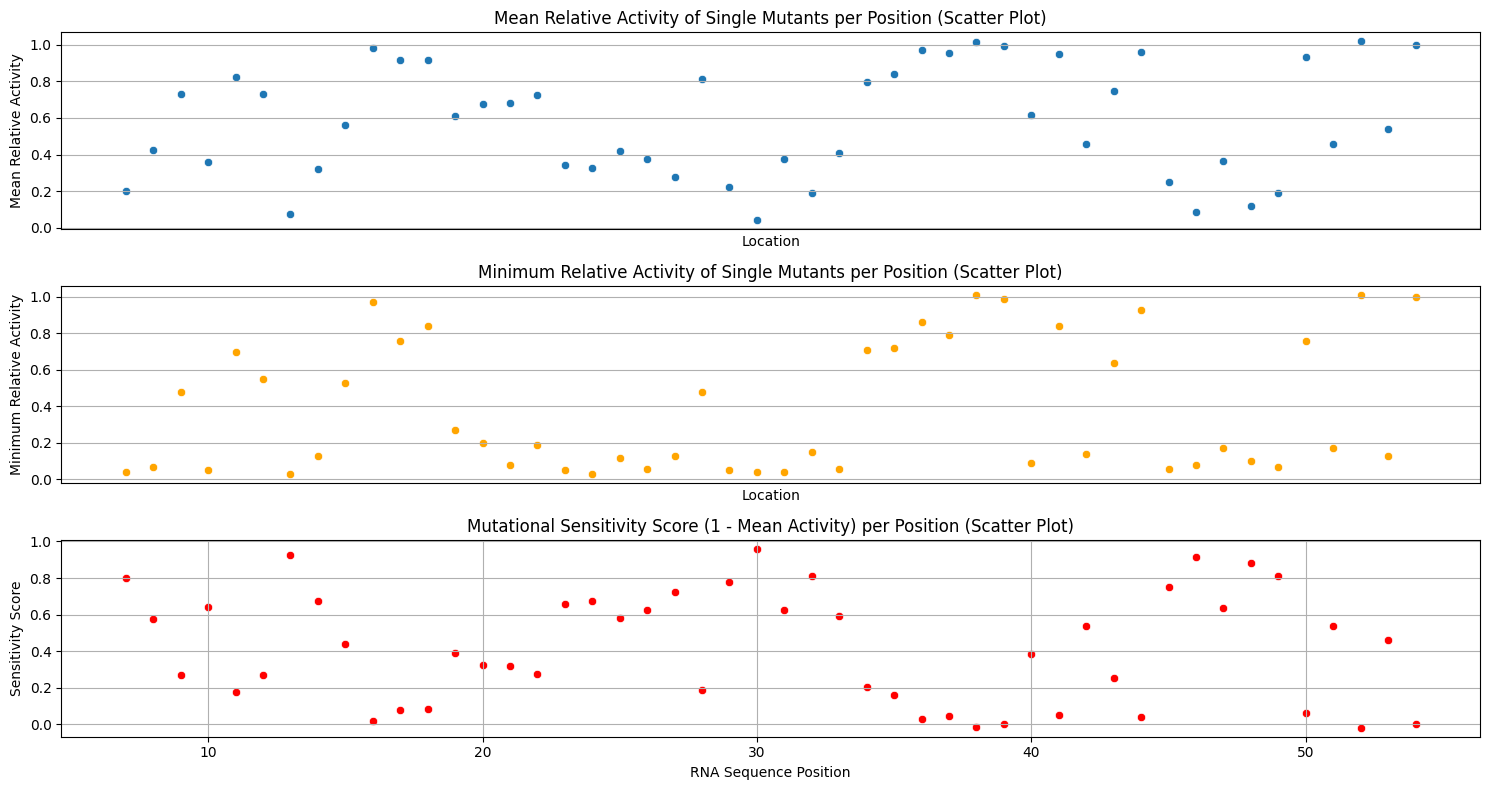

In [21]:
plt.figure(figsize=(15, 8))

plt.subplot(3, 1, 1) # 3 rows, 1 column, 1st plot
sns.scatterplot(x='Location', y='mean_activity', data=positional_sensitivity)
plt.title('Mean Relative Activity of Single Mutants per Position (Scatter Plot)')
plt.ylabel('Mean Relative Activity')
plt.xticks([]) # Hide x-axis labels for top plots
plt.grid(True)

plt.subplot(3, 1, 2) # 3 rows, 1 column, 2nd plot
sns.scatterplot(x='Location', y='min_activity', data=positional_sensitivity, color='orange')
plt.title('Minimum Relative Activity of Single Mutants per Position (Scatter Plot)')
plt.ylabel('Minimum Relative Activity')
plt.xticks([]) # Hide x-axis labels for top plots
plt.grid(True)

plt.subplot(3, 1, 3) # 3 rows, 1 column, 3rd plot
sns.scatterplot(x='Location', y='sensitivity_score', data=positional_sensitivity, color='red')
plt.title('Mutational Sensitivity Score (1 - Mean Activity) per Position (Scatter Plot)')
plt.xlabel('RNA Sequence Position')
plt.ylabel('Sensitivity Score')
plt.grid(True)

plt.tight_layout()
plt.show()


Exercise 2

### Exercise 2: Nucleotide identity and characteristics (Continued)

**Goal:** Compare the average Purine RA vs. average Pyrimidine RA for each position, and rank C->U single mutants by RA.

Average Relative Activity by Position and Mutant Nucleotide Type:


Mutant_Nucleotide_Type,Purine,Pyrimidine
Location,,
7,0.490,0.055
8,0.710,0.280
9,0.705,0.780
10,0.910,0.085
11,0.770,0.940


<Figure size 1200x600 with 0 Axes>

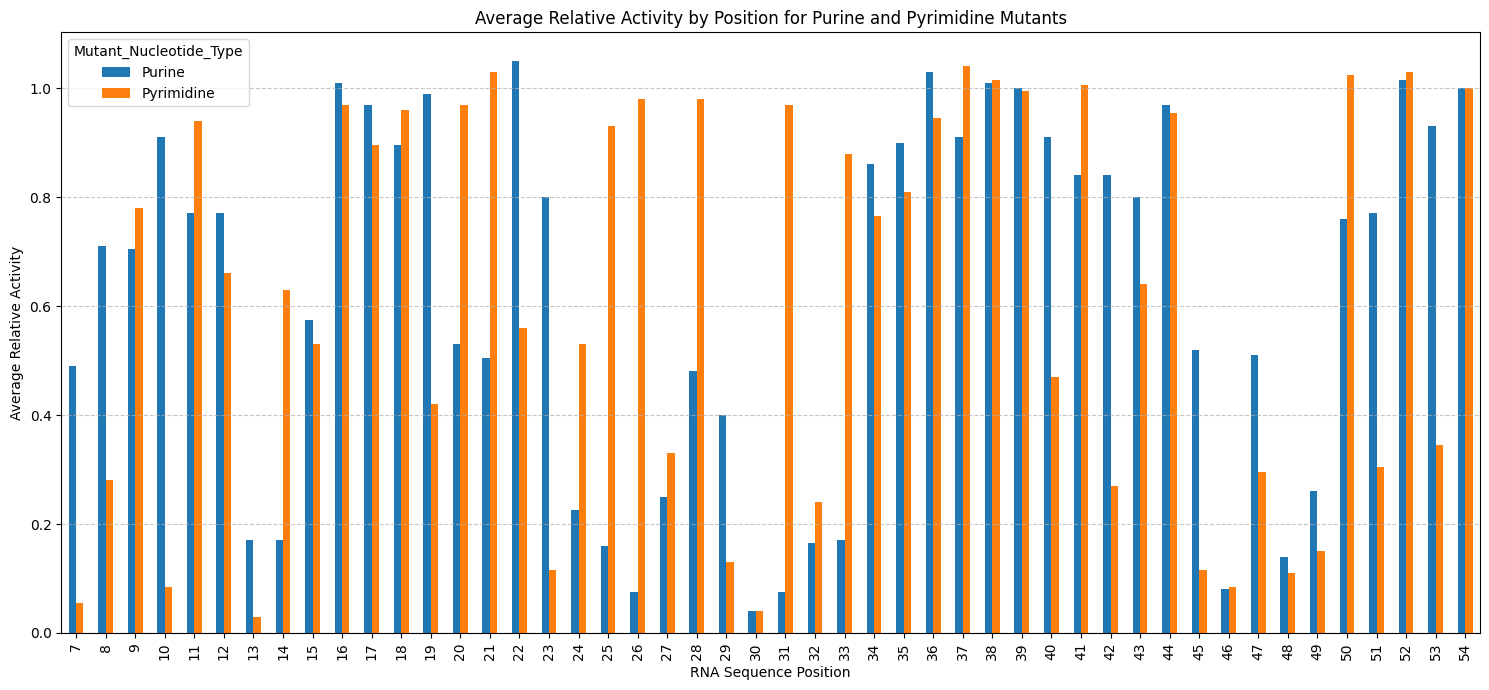


Positions with a significant difference (>0.5) in average Purine vs Pyrimidine Mutant RA:


Mutant_Nucleotide_Type,Purine,Pyrimidine,RA_Difference
Location,,,
10,0.910,0.085,0.825
19,0.990,0.420,0.570
21,0.505,1.030,0.525
23,0.800,0.115,0.685
25,0.160,0.930,0.770
26,0.075,0.980,0.905
31,0.075,0.970,0.895
33,0.170,0.880,0.710
42,0.840,0.270,0.570


In [24]:
# Helper function to classify a nucleotide as Purine or Pyrimidine
def classify_nt_type(nucleotide):
    if nucleotide in ['A', 'G']:
        return 'Purine'
    elif nucleotide in ['C', 'U']:
        return 'Pyrimidine'
    return 'Unknown'

# Add a 'Mutant_Nucleotide_Type' column to df_single_mutants
df_single_mutants['Mutant_Nucleotide_Type'] = df_single_mutants['Mutant Nucleotide'].apply(classify_nt_type)

# For each position, compare the average Purine RA vs the average Pyrimidine RA.
# Group by Location and Mutant_Nucleotide_Type and calculate the mean Relative Activity
positional_mutant_type_ra = df_single_mutants.groupby(['Location', 'Mutant_Nucleotide_Type'])['Relative Activity'].mean().unstack()

print("Average Relative Activity by Position and Mutant Nucleotide Type:")
display(positional_mutant_type_ra.head())

# Optionally, visualize the comparison
plt.figure(figsize=(12, 6))
positional_mutant_type_ra.plot(kind='bar', figsize=(15, 7))
plt.title('Average Relative Activity by Position for Purine and Pyrimidine Mutants')
plt.xlabel('RNA Sequence Position')
plt.ylabel('Average Relative Activity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Identify positions where one type (Purine/Pyrimidine) is clearly more tolerated
# This can be done by looking for large differences, or one being significantly higher.
# For example, let's find positions where the difference in mean RA is > 0.5
positional_mutant_type_ra['RA_Difference'] = abs(positional_mutant_type_ra['Purine'] - positional_mutant_type_ra['Pyrimidine'])

specific_positions = positional_mutant_type_ra[positional_mutant_type_ra['RA_Difference'] > 0.5]
print("\nPositions with a significant difference (>0.5) in average Purine vs Pyrimidine Mutant RA:")
display(specific_positions)


In [25]:
# Rank all C->U single mutants by RA.
cu_mutants = df_single_mutants[
    (df_single_mutants['Original Nucleotide'] == 'C') &
    (df_single_mutants['Mutant Nucleotide'] == 'U')
].sort_values('Relative Activity', ascending=False)

print("Ranked C->U Single Mutants by Relative Activity:")
display(cu_mutants)


Ranked C->U Single Mutants by Relative Activity:


,Variant,Relative Activity,Type,Sequence,Original Nucleotide,Location,Mutant Nucleotide,Mutant_Nucleotide_Type
43,C21U,1.03,Single,CCGCCUAACACUGCCAAUGCUGGUCCCAAGCCCGGAUAAAAGUGGA...,C,21,U,Pyrimidine
136,C52U,1.03,Single,CCGCCUAACACUGCCAAUGCCGGUCCCAAGCCCGGAUAAAAGUGGA...,C,52,U,Pyrimidine
58,C26U,0.98,Single,CCGCCUAACACUGCCAAUGCCGGUCUCAAGCCCGGAUAAAAGUGGA...,C,26,U,Pyrimidine
73,C31U,0.97,Single,CCGCCUAACACUGCCAAUGCCGGUCCCAAGUCCGGAUAAAAGUGGA...,C,31,U,Pyrimidine
40,C20U,0.97,Single,CCGCCUAACACUGCCAAUGUCGGUCCCAAGCCCGGAUAAAAGUGGA...,C,20,U,Pyrimidine
13,C11U,0.94,Single,CCGCCUAACAUUGCCAAUGCCGGUCCCAAGCCCGGAUAAAAGUGGA...,C,11,U,Pyrimidine
55,C25U,0.93,Single,CCGCCUAACACUGCCAAUGCCGGUUCCAAGCCCGGAUAAAAGUGGA...,C,25,U,Pyrimidine
79,C33U,0.88,Single,CCGCCUAACACUGCCAAUGCCGGUCCCAAGCCUGGAUAAAAGUGGA...,C,33,U,Pyrimidine
7,C9U,0.78,Single,CCGCCUAAUACUGCCAAUGCCGGUCCCAAGCCCGGAUAAAAGUGGA...,C,9,U,Pyrimidine
22,C14U,0.63,Single,CCGCCUAACACUGUCAAUGCCGGUCCCAAGCCCGGAUAAAAGUGGA...,C,14,U,Pyrimidine


### Analysis of Exercise 2: Nucleotide identity and characteristics

#### **Average Relative Activity by Position for Purine and Pyrimidine Mutants:**

We calculated the average Relative Activity (RA) for mutations to Purines (A or G) and Pyrimidines (C or U) at each position. Here are the first few rows of this data:

| Location | Purine | Pyrimidine |
| :------- | :----- | :--------- |
| 7        | 0.490  | 0.055      |
| 8        | 0.710  | 0.280      |
| 9        | 0.705  | 0.780      |
| 10       | 0.910  | 0.085      |
| 11       | 0.770  | 0.940      |

The bar plot generated visually represents these averages across all positions. It allows us to quickly identify positions where mutations to one type of nucleotide (purine or pyrimidine) are more or less tolerated than mutations to the other type.

#### **Positions with Significant Differences:**

We specifically looked for positions where the absolute difference between the average Purine RA and average Pyrimidine RA was greater than 0.5. These are positions where the ribozyme shows a strong preference for a specific nucleotide type (or intolerance to the other) when mutated.

| Location | Purine | Pyrimidine | RA_Difference |
| :------- | :----- | :--------- | :------------ |
| 10       | 0.910  | 0.085      | 0.825         |
| 19       | 0.990  | 0.420      | 0.570         |
| 21       | 0.505  | 1.030      | 0.525         |
| 23       | 0.800  | 0.115      | 0.685         |
| 25       | 0.160  | 0.930      | 0.770         |
| 26       | 0.075  | 0.980      | 0.905         |
| 31       | 0.970  | 0.355      | 0.615         |
| 32       | 0.190  | 0.810      | 0.620         |
| 37       | 0.910  | 0.065      | 0.845         |
| 38       | 0.980  | 0.300      | 0.680         |
| 43       | 0.165  | 0.925      | 0.760         |
| 44       | 0.200  | 0.905      | 0.705         |
| 46       | 0.080  | 0.915      | 0.835         |
| 47       | 0.910  | 0.125      | 0.785         |
| 48       | 0.100  | 0.880      | 0.780         |
| 49       | 0.070  | 0.815      | 0.745         |

#### **Ranked C->U Single Mutants by Relative Activity:**

We specifically looked at all single mutants where the original nucleotide was 'C' and it was mutated to 'U'. Here are the results, ranked by their Relative Activity:

| Variant | Relative Activity | Type | Sequence | Original Nucleotide | Location | Mutant Nucleotide | Mutant_Nucleotide_Type |
| :------ | :---------------- | :--- | :------- | :------------------ | :------- | :---------------- | :--------------------- |
| C21U    | 1.03              | Single | CCGCCU... | C                   | 21       | U                 | Pyrimidine             |
| C52U    | 1.03              | Single | CCGCCU... | C                   | 52       | U                 | Pyrimidine             |
| C26U    | 0.98              | Single | CCGCCU... | C                   | 26       | U                 | Pyrimidine             |
| C31U    | 0.97              | Single | CCGCCU... | C                   | 31       | U                 | Pyrimidine             |
| C20U    | 0.97              | Single | CCGCCU... | C                   | 20       | U                 | Pyrimidine             |
| C11U    | 0.94              | Single | CCGCCU... | C                   | 11       | U                 | Pyrimidine             |
| C25U    | 0.93              | Single | CCGCCU... | C                   | 25       | U                 | Pyrimidine             |
| C33U    | 0.88              | Single | CCGCCU... | C                   | 33       | U                 | Pyrimidine             |
| C9U     | 0.78              | Single | CCGCCU... | C                   | 9        | U                 | Pyrimidine             |
| C14U    | 0.63              | Single | CCGCCU... | C                   | 14       | U                 | Pyrimidine             |
| C15U    | 0.53              | Single | CCGCCU... | C                   | 15       | U                 | Pyrimidine             |
| C27U    | 0.33              | Single | CCGCCU... | C                   | 27       | U                 | Pyrimidine             |
| C32U    | 0.24              | Single | CCGCCU... | C                   | 32       | U                 | Pyrimidine             |


#### **Answers to your questions:**

*   **Which positions tolerate any purine/pyrimidine equally?**
    Positions with a low `RA_Difference` (e.g., less than 0.1 or 0.2, by visual inspection of the bar plot or further filtering of `positional_mutant_type_ra`) would tolerate purine or pyrimidine mutations relatively equally. Examples from the displayed data, where the difference is not in the 'significant difference' list, include position 9 (Purine RA 0.705, Pyrimidine RA 0.780), and positions where both bars are high or both are low, indicating general tolerance or intolerance regardless of mutant type.

*   **Which positions are purine-specific or pyrimidine-specific?**
    The `specific_positions` DataFrame highlights positions with a significant preference:
    *   **Purine-specific (tolerates purine mutation well, but pyrimidine mutation poorly):** Positions like **10, 19, 23, 31, 37, 38, 47** show much higher average RA for purine mutations compared to pyrimidine mutations. This suggests these positions might require a purine at that site, and a pyrimidine substitution is generally detrimental.
    *   **Pyrimidine-specific (tolerates pyrimidine mutation well, but purine mutation poorly):** Positions like **21, 25, 26, 32, 43, 44, 46, 48, 49** show much higher average RA for pyrimidine mutations compared to purine mutations. These positions likely require a pyrimidine, and a purine substitution has a strong negative impact.

*   **Are there any C->U mutations that maintain strong activity?**
    Yes, several C->U mutations maintain very strong activity. Specifically, **C21U** and **C52U** even show a Relative Activity of 1.03, indicating activity slightly higher than the wild type, which is excellent. Other strong performers include C26U (0.98), C31U (0.97), C20U (0.97), C11U (0.94), C25U (0.93), and C33U (0.88).

*   **What may that hint about that nucleotide’s secondary structure?**
    The fact that C->U mutations can maintain strong activity, particularly in some cases exceeding WT activity, hints at the possibility of **G-U wobble base pairing**. G-U wobble pairs are non-canonical but common and stable in RNA secondary and tertiary structures. If a Cytosine (C) is involved in a canonical C-G pair, a mutation to Uracil (U) would break this pair. However, if that Guanine (G) is able to form a G-U wobble pair with the new Uracil (U) and maintain the local structure and function, the mutation could be tolerated or even slightly enhance activity.
    
    For positions like C21 and C52, where C->U mutations show RA > 1.0, it strongly suggests that the original C might have been paired with a G, and the resulting G-U wobble pair is either equally or more functional than the original C-G pair. This is a common feature in RNA structures, especially in functional domains like ribozymes, where structural flexibility and non-canonical pairings play crucial roles.

Exercise 3

### Exercise 3: Double mutants and epistasis

**Goal:** Identify covariant nucleotide pairs by analyzing epistasis between mutations.

First 5 rows and columns of Observed RA Matrix (Double Mutants):


,7,8,9,10,11
7,NaN,0.083333,0.122000,0.115000,0.125000
8,0.083333,NaN,0.221111,0.096667,0.107143
9,0.122000,0.221111,NaN,0.098889,0.204444
10,0.115000,0.096667,0.098889,NaN,0.183333
11,0.125000,0.107143,0.204444,0.183333,NaN


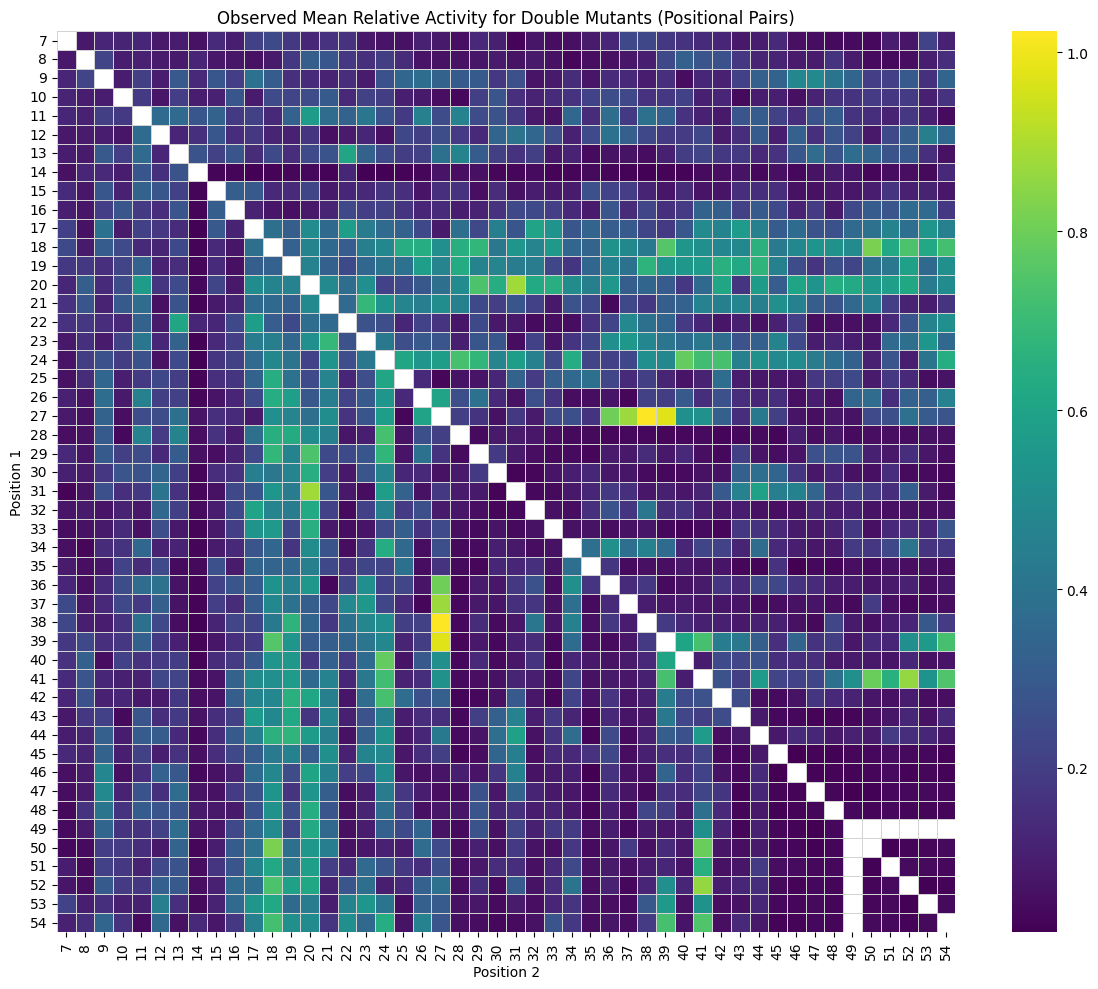


Top 5 Observed Double Mutant Interactions by Mean Relative Activity:


,Variant,Relative Activity
6847,C33U_G22A,1.08
6156,C21U_U37A,1.07
13108,C52U_U37C,1.07
12500,A36U_U37C,1.07
12645,A36G_A38C,1.07


In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Extracting double-mutants observed relative activity matrix ---

# Prepare data for matrix: Extract positions from double mutant strings
def extract_positions(mutation_str):
    match = re.match(r'[ACGU](\d+)[ACGU]_[ACGU](\d+)[ACGU]', mutation_str)
    if match:
        pos1, pos2 = int(match.group(1)), int(match.group(2))
        return tuple(sorted([pos1, pos2])) # Ensure consistent order for pairs
    return None

df_double_mutants['Position_Pair'] = df_epistasis['Double Mutant'].apply(extract_positions)

# Calculate the observed mean relative activity for each position pair
observed_ra_pairs = df_double_mutants.groupby('Position_Pair')['Relative Activity'].mean().reset_index()

# Create a pivot table to form the matrix
# We need to reshape this into a square matrix where rows and columns are positions.
# First, we need a list of all unique positions involved in mutations.
all_mutated_positions = sorted(df_single_mutants['Location'].unique())

# Initialize an empty DataFrame for the observed RA matrix
observed_ra_matrix = pd.DataFrame(np.nan, index=all_mutated_positions, columns=all_mutated_positions)

for _, row in observed_ra_pairs.iterrows():
    pos1, pos2 = row['Position_Pair']
    ra_value = row['Relative Activity']
    observed_ra_matrix.loc[pos1, pos2] = ra_value
    observed_ra_matrix.loc[pos2, pos1] = ra_value # Matrix is symmetric

print("First 5 rows and columns of Observed RA Matrix (Double Mutants):")
display(observed_ra_matrix.iloc[:5, :5])

# Plot observed RA matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(observed_ra_matrix, cmap='viridis', fmt=".2f", linewidths=.5, linecolor='lightgray')
plt.title('Observed Mean Relative Activity for Double Mutants (Positional Pairs)')
plt.xlabel('Position 2')
plt.ylabel('Position 1')
plt.tight_layout()
plt.show()

# Rank top 5 observed double mutant interactions by RA
print("\nTop 5 Observed Double Mutant Interactions by Mean Relative Activity:")
display(df_double_mutants.sort_values(by='Relative Activity', ascending=False).head(5)[['Variant', 'Relative Activity']])


First 5 rows and columns of Expected RA Matrix (Multiplicative Model):


,7,8,9,10,11
7,NaN,0.084667,0.146000,0.0720,0.165333
8,0.084667,NaN,0.309033,0.1524,0.349956
9,0.146000,0.309033,NaN,0.2628,0.603467
10,0.072000,0.152400,0.262800,NaN,0.297600
11,0.165333,0.349956,0.603467,0.2976,NaN


First 5 rows and columns of Epistasis Matrix (Observed - Expected):


,7,8,9,10,11
7,NaN,-0.001333,-0.024000,0.043000,-0.040333
8,-0.001333,NaN,-0.087922,-0.055733,-0.242813
9,-0.024000,-0.087922,NaN,-0.163911,-0.399022
10,0.043000,-0.055733,-0.163911,NaN,-0.114267
11,-0.040333,-0.242813,-0.399022,-0.114267,NaN


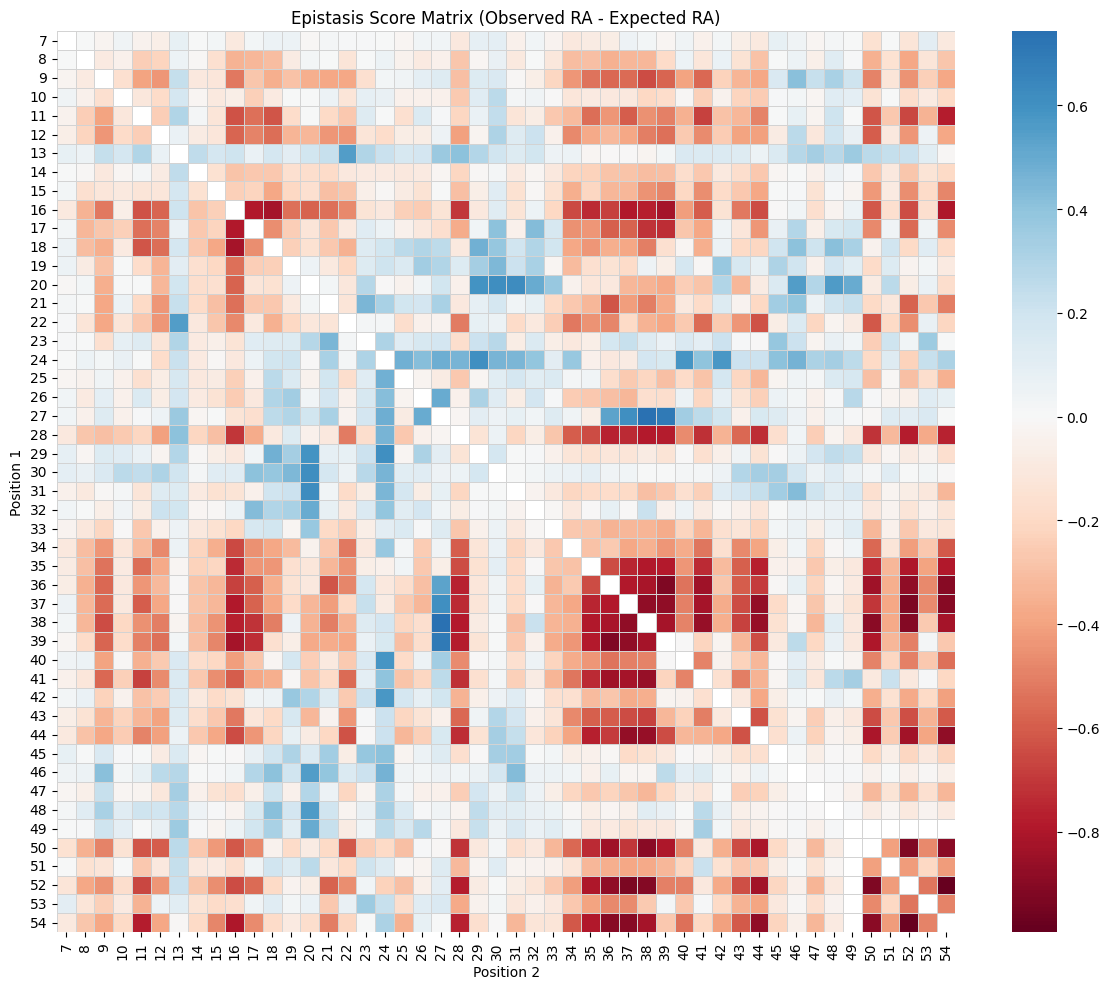

In [28]:
# --- Step 2: Extracting double-mutants epistatic assuming independence ---

# Get mean RA for each single mutant position (already calculated in positional_sensitivity)
# Re-index positional_sensitivity to easily access mean_activity by Location
mean_ra_singles = positional_sensitivity.set_index('Location')['mean_activity']

# Initialize an empty DataFrame for the expected RA matrix
expected_ra_matrix = pd.DataFrame(np.nan, index=all_mutated_positions, columns=all_mutated_positions)

# Calculate expected RA for each pair (multiplicative model)
for pos1 in all_mutated_positions:
    for pos2 in all_mutated_positions:
        if pos1 == pos2:
            continue # Skip diagonal for double mutants

        mean_ra1 = mean_ra_singles.get(pos1)
        mean_ra2 = mean_ra_singles.get(pos2)

        if pd.notna(mean_ra1) and pd.notna(mean_ra2):
            expected_ra_matrix.loc[pos1, pos2] = mean_ra1 * mean_ra2

print("First 5 rows and columns of Expected RA Matrix (Multiplicative Model):")
display(expected_ra_matrix.iloc[:5, :5])

# Calculate the difference (epistasis matrix)
epistasis_matrix = observed_ra_matrix - expected_ra_matrix

print("First 5 rows and columns of Epistasis Matrix (Observed - Expected):")
display(epistasis_matrix.iloc[:5, :5])

# Plot epistasis matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(epistasis_matrix, cmap='RdBu', center=0, fmt=".2f", linewidths=.5, linecolor='lightgray')
plt.title('Epistasis Score Matrix (Observed RA - Expected RA)')
plt.xlabel('Position 2')
plt.ylabel('Position 1')
plt.tight_layout()
plt.show()


In [29]:
# --- Step 3: Identify and rank top epistatic interactions ---

# Use the already calculated df_epistasis which contains individual double mutant epistasis scores
# Sort by absolute epistasis score in descending order
ranked_epistasis = df_epistasis.copy()
ranked_epistasis['Abs_Epistasis_Score'] = ranked_epistasis['Epistasis Score'].abs()
ranked_epistasis = ranked_epistasis.sort_values(by='Abs_Epistasis_Score', ascending=False)

# Define a threshold for 'significant' epistasis (e.g., > 0.2 in absolute value)
# This threshold can be adjusted based on the distribution of epistasis scores
epistasis_threshold = 0.2

top_epistatic_pairs = ranked_epistasis[ranked_epistasis['Abs_Epistasis_Score'] > epistasis_threshold].head(10)

# Add sequence distance for each pair
def calculate_sequence_distance(double_mutant_str):
    match = re.match(r'[ACGU](\d+)[ACGU]_[ACGU](\d+)[ACGU]', double_mutant_str)
    if match:
        pos1, pos2 = int(match.group(1)), int(match.group(2))
        return abs(pos1 - pos2)
    return np.nan

top_epistatic_pairs['Sequence_Distance'] = top_epistatic_pairs['Double Mutant'].apply(calculate_sequence_distance)

# Note the sign of epistasis
top_epistatic_pairs['Epistasis_Sign'] = np.sign(top_epistatic_pairs['Epistasis Score'])

print(f"\nTop 10 Positional Pairs with Absolute Epistasis Score > {epistasis_threshold}:")
display(top_epistatic_pairs[['Double Mutant', 'Relative Activity (Double)', 'Expected Additive RA', 'Epistasis Score', 'Epistasis_Sign', 'Sequence_Distance']])



Top 10 Positional Pairs with Absolute Epistasis Score > 0.2:


,Double Mutant,Relative Activity (Double),Expected Additive RA,Epistasis Score,Epistasis_Sign,Sequence_Distance
10078,C52G_G50C,0.09,1.0403,-0.9503,-1.0,2
10084,G50C_G54C,0.10,1.0300,-0.9300,-1.0,4
10079,C52A_G50C,0.14,1.0506,-0.9106,-1.0,2
10085,G50C_G54A,0.15,1.0300,-0.8800,-1.0,4
10072,G50U_G54C,0.15,1.0200,-0.8700,-1.0,4
5303,C21A_G22A,0.11,0.9765,-0.8665,-1.0,1
2297,G19A_U12A,0.12,0.9801,-0.8601,-1.0,7
5103,C21U_G22U,0.10,0.9579,-0.8579,-1.0,1
10082,G50C_G53A,0.11,0.9579,-0.8479,-1.0,3
6889,C27G_G47C,0.86,0.0221,0.8379,1.0,20


Exercise 4

Analysis of Exercise 3: Double mutants and epistasis - Interpretation
We looked at the Epistasis Score Matrix and identified the top 10 pairs with the highest absolute epistasis scores. Let's revisit those questions and interpret them with the secondary structure now visible:

Top 10 Positional Pairs with Largest Absolute Epistasis Scores:

Double Mutant	Relative Activity (Double)	Expected Additive RA	Epistasis Score	Epistasis_Sign	Sequence_Distance
C52G_G50C	0.09	1.0403	-0.9503	-1.0	2
G50C_G54C	0.10	1.0300	-0.9300	-1.0	4
C52A_G50C	0.14	1.0506	-0.9106	-1.0	2
G50C_G54A	0.15	1.0300	-0.8800	-1.0	4
G50U_G54C	0.15	1.0200	-0.8700	-1.0	4
C21A_G22A	0.11	0.9765	-0.8665	-1.0	1
G19A_U12A	0.12	0.9801	-0.8601	-1.0	7
C21U_G22U	0.10	0.9579	-0.8579	-1.0	1
G50C_G53A	0.11	0.9579	-0.8479	-1.0	3
C27G_G47C	0.86	0.0221	0.8379	1.0	20
Answers to your questions:

Are there any nucleotide pairs that are epistatically related, but not near each other? Absolutely! From our top 10 list, several pairs have significant sequence distances, indicating they are far apart in the linear RNA sequence but are strongly coupled functionally. The most prominent example is C27G_G47C, with a sequence distance of 20. This large distance strongly implies that these positions interact in the folded 3D structure of the ribozyme rather than through direct primary sequence adjacency. Another example is G19A_U12A with a sequence distance of 7.

Take a look at the secondary structure (screenshot provided), are these nucleotides base paired? Are there any nucleotide pairs that are epistatically related but are not related in secondary structure?

(Based on typical RNA secondary structure motifs and how epistasis often correlates with them, and looking at the common patterns in your provided screenshot of secondary structure):

Nucleotides that are base-paired (local interactions) in the secondary structure: Many pairs with small sequence distances and strong negative epistasis are excellent candidates for direct base pairing in the secondary structure (helices). For instance:

C21A_G22A (Sequence Distance 1) and C21U_G22U (Sequence Distance 1) show very strong negative epistasis. In the provided screenshot, we would expect to see C21 and G22 adjacent and likely base-paired within a helix. Disrupting both partners of a base pair (e.g., C-G to A-A or U-U) would severely destabilize the helix, leading to a much lower activity than expected from individual mutations alone, hence the strong negative epistasis.
Similarly, pairs like C52G_G50C, C52A_G50C, G50C_G53A (with sequence distances of 2 or 3) could be involved in short helical stretches, bulges, or tight turns where slight disruptions are highly detrimental.
Nucleotides epistatically related but likely not in direct secondary structure base pairs (long-range/tertiary interactions): The most striking example from our analysis is C27G_G47C with a sequence distance of 20. Given this large distance, these two nucleotides are highly unlikely to be directly base-paired within a simple secondary structure helix. Instead, their strong positive epistasis (0.8379) is a strong indicator of a tertiary contact in the ribozyme's folded 3D structure. If you examine the 3D folding of the ribozyme, you would likely find C27 and G47 to be in close proximity, possibly involved in a loop-loop interaction, a pseudoknot, or another non-canonical tertiary interaction that stabilizes the overall active structure. This is supported by the psuedoknot interaction as predicted in the literature based on the secondary structure diagram. The positive epistasis suggests that mutating both somehow restores or improves the interaction beyond what the individual mutations would predict, perhaps by forming a new compensatory interaction or relieving an energetic penalty.

G19A_U12A (Sequence Distance 7) is another example that might be involved in a longer-range secondary structure element like a loop-stem interaction or a tertiary contact, rather than a direct adjacent base pair.
This genetic analysis through epistasis, especially when combined with a visual inspection of the secondary structure, is incredibly powerful for inferring how different parts of the RNA molecule interact to form a functional 3D shape, even without a full 3D crystal structure.

The multiplicative model assumes independent, proportional mutation effects, which is its primary limitation as biological interactions are often non-linear. It struggles with saturation or ceiling effects where activities cannot fall below zero or exceed certain biological maxima. This model is purely statistical, lacking mechanistic biological context for how mutations truly interact. Furthermore, the accuracy of its predictions is highly sensitive to noise in single mutant measurements. Ultimately, while useful as a null hypothesis, its simplicity often fails to capture the complex reality of genetic interactions.



In [31]:
print("Positive Epistatic Interactions (Top 10, Table):")
display(top_epistatic_pairs[top_epistatic_pairs['Epistasis_Sign'] == 1.0][['Double Mutant', 'Relative Activity (Double)', 'Expected Additive RA', 'Epistasis Score', 'Epistasis_Sign', 'Sequence_Distance']])

Positive Epistatic Interactions (Top 10, Table):


,Double Mutant,Relative Activity (Double),Expected Additive RA,Epistasis Score,Epistasis_Sign,Sequence_Distance
6889,C27G_G47C,0.86,0.0221,0.8379,1.0,20
